# House Price Prediction

## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [11]:
import urllib.request

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
urllib.request.urlretrieve(url, "house_data.csv")

df = pd.read_csv("house_data.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head())

Dataset loaded: 20640 rows, 10 columns
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


## 3. Prepare Data

In [12]:
df = df.dropna()
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=float)

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Features: 12
Samples: 20433


## 4. Split Data (80% Train, 20% Test)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples")

Training: 16346 samples
Testing: 4087 samples


## 5. Train Model

In [14]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 6. Evaluate Model

In [15]:
y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred) * 100

print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 82.60%


## 7. Visualize Results

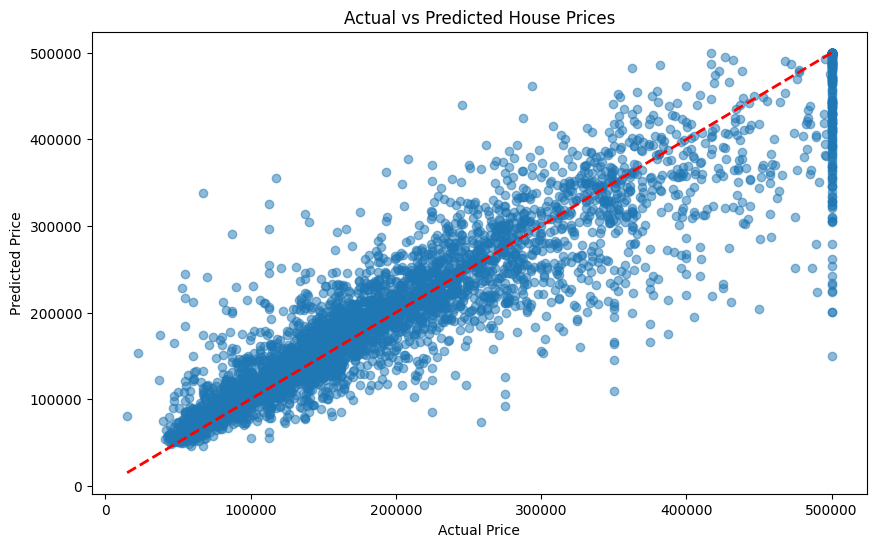

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

## 8. Sample Predictions

In [17]:
sample_X = X_test[:5]
sample_y = y_test.iloc[:5]
predictions = model.predict(sample_X)

print("Sample Predictions:")
for i in range(5):
    print(f"House {i+1}: Predicted=${predictions[i]:,.0f}, Actual=${sample_y.iloc[i]:,.0f}")

print(f"\nOverall Accuracy: {accuracy:.2f}%")

Sample Predictions:
House 1: Predicted=$218,806, Actual=$245,800
House 2: Predicted=$151,202, Actual=$137,900
House 3: Predicted=$190,018, Actual=$218,200
House 4: Predicted=$146,361, Actual=$220,800
House 5: Predicted=$168,285, Actual=$170,500

Overall Accuracy: 82.60%


## 9. Custom Prediction

In [18]:
custom_house = {
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41.0,
    'total_rooms': 880.0,
    'total_bedrooms': 129.0,
    'population': 322.0,
    'households': 126.0,
    'median_income': 8.3252,
    'ocean_proximity_INLAND': 0.0,
    'ocean_proximity_ISLAND': 0.0,
    'ocean_proximity_NEAR BAY': 1.0,
    'ocean_proximity_NEAR OCEAN': 0.0
}

custom_df = pd.DataFrame([custom_house])
custom_df = custom_df[X.columns]
custom_scaled = scaler.transform(custom_df)
predicted_price = model.predict(custom_scaled)[0]

print(f"Predicted Price: ${predicted_price:,.2f}")

Predicted Price: $449,321.37
